In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import tensorflow as tf

In [65]:
def encode_objects(df):
    for col, dtype in df.dtypes.items():
        if dtype == 'object' and col != 'label':
            encoder = LabelEncoder()
            df[col] = encoder.fit_transform(df[col])
    return df

In [66]:
columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
        "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", 
        "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
        "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
        "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", 
        "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
        "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"]

df_init = pd.read_csv("datasets/kddcup1999/kddcup.data.corrected", sep=",", names=columns, index_col=None)

# Pre-processing

In [67]:
# Keeping only the features selected in the paper A stacking... by Smitha Rajagopal

keep_cols = ['logged_in', 'count', 'dst_host_count', 'protocol_type', 'srv_count', 'dst_host_same_src_port_rate', 'srv_diff_host_rate', 'dst_bytes', 'serror_rate', 'srv_serror_rate', 'same_srv_rate', 'flag', 'dst_host_same_srv_rate', 'dst_host_srv_count', 'dst_host_srv_diff_host_rate', 'label']

df_feature_selected = df_init[df_init.columns.intersection(keep_cols)]

In [68]:
df_feature_selected_encoded = encode_objects(df_feature_selected)

df_feature_selected_encoded['label'] = df_feature_selected_encoded['label'].apply(lambda x: 0 if x=='normal.' else 1)

df_feature_selected_encoded = df_feature_selected_encoded.drop(df_feature_selected_encoded[df_feature_selected_encoded['dst_bytes'] > 2e8].index)

C:\Users\David\AppData\Local\Temp\ipykernel_24700\847671518.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoder.fit_transform(df[col])
C:\Users\David\AppData\Local\Temp\ipykernel_24700\847671518.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoder.fit_transform(df[col])
C:\Users\David\AppData\Local\Temp\ipykernel_24700\3015086583.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

In [135]:
normal = df_feature_selected_encoded.query('label == 0').sample(100000)
attack = df_feature_selected_encoded.query('label == 1').sample(500)


In [136]:
# Conduct a train-test split    
train, test = train_test_split(normal, test_size=0.2, random_state=42)

y_train = train['label']
x_train = train.drop('label', axis=1)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

test = pd.concat([test, attack]).sample(frac=1)
y_test = test['label']
x_test = test.drop('label', axis=1)

print("Shapes")
print(f"x_train:{x_train.shape}\ny_train:{y_train.shape}")
print(f"\nx_train:{x_val.shape}\ny_train:{y_val.shape}")
print(f"\nx_test:{x_test.shape}\ny_test:{y_test.shape}")

Shapes
x_train:(64000, 15)
y_train:(64000,)

x_train:(16000, 15)
y_train:(16000,)

x_test:(20500, 15)
y_test:(20500,)


## Scaling features

In [137]:
scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

# Model

In [138]:
%load_ext tensorboard
%tensorboard --logdir logs/autoencoder_kdd/

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 23540), started 1:38:15 ago. (Use '!kill 23540' to kill it.)

In [139]:
# data dimensions // hyperparameters 
input_dim = x_train_scaled.shape[1]
BATCH_SIZE = 64
EPOCHS = 100

# https://keras.io/layers/core/
autoencoder = tf.keras.models.Sequential([
    
    # deconstruct / encode
    tf.keras.layers.Input(shape=(input_dim,)), 
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),

    # bottleneck layer/latent representation
    tf.keras.layers.Dense(2, activation='relu'),
    
    # reconstruction / decode
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(input_dim, activation='softmax')
    
])

# https://keras.io/api/models/model_training_apis/
autoencoder.compile(optimizer="adam", 
                    loss="mse",
                    metrics=["acc"])

# print an overview of our model
autoencoder.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 8)              │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 15)             │           135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361 (1.41 KB)

 Trainable params: 361 (1.41 KB)

 Non-trainable params: 0 (0.00 B)

In [140]:
from datetime import datetime

# current date and time
yyyymmddHHMM = datetime.now().strftime('%Y%m%d%H%M')

# new folder for a new run
log_subdir = f'{yyyymmddHHMM}_batch{BATCH_SIZE}_layers{len(autoencoder.layers)}'

# define our early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    patience=5,
    verbose=1, 
    mode='min',
    restore_best_weights=True
)

save_model = tf.keras.callbacks.ModelCheckpoint(
    filepath='models/autoencoder_kdd_best_weights.keras', 
    save_best_only=True,
    monitor='val_loss',
    verbose=0,
    mode='min'
)

tensorboard = tf.keras.callbacks.TensorBoard(
    f'logs/autoencoder_kdd/{log_subdir}',
    update_freq='batch'
)

# callbacks argument only takes a list
cb = [early_stop, save_model, tensorboard]

## Training

In [141]:
history = autoencoder.fit(
    x_train_scaled, x_train_scaled,
    shuffle=True,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    validation_data=(x_val_scaled, x_val_scaled)
)

Epoch 1/100


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.1248 - loss: 0.9861 - val_acc: 0.4869 - val_loss: 0.8281
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.5153 - loss: 0.9238 - val_acc: 0.5537 - val_loss: 0.7963
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.5515 - loss: 0.8929 - val_acc: 0.5627 - val_loss: 0.7917
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.5618 - loss: 0.8548 - val_acc: 0.5652 - val_loss: 0.7906
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.5623 - loss: 0.8819 - val_acc: 0.5676 - val_loss: 0.7892
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.5650 - loss: 0.8637 - val_acc: 0.5689 - val_loss: 0.7886
Epoch 7/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.5687 - loss: 0.8792 - val_acc: 0.5713 - val_loss: 0.7872
Epoch 8/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.5733 - loss: 0.8776 - val_acc: 0.5810 - val_loss: 0.7854
Epoch 9/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3

## Computing threshold for anomaly detection

In [142]:
reconstructions = autoencoder.predict(x_test_scaled)

mse = np.mean(np.power(x_test_scaled - reconstructions, 2), axis=1)

641/641 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


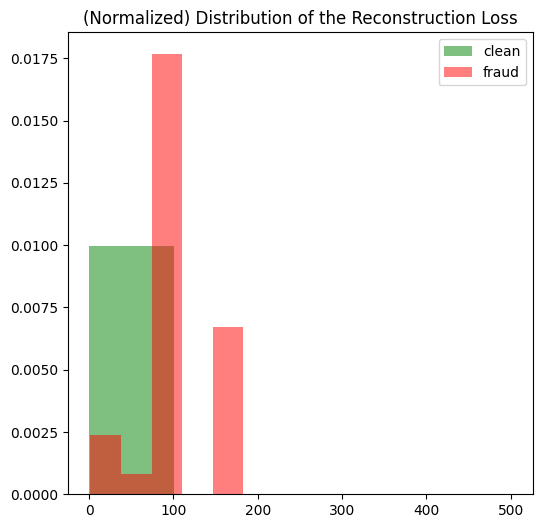

In [143]:
clean = mse[y_test==0]
fraud = mse[y_test==1]

fig, ax = plt.subplots(figsize=(6,6))

ax.hist(clean, bins=5, density=True, label="clean", alpha=.5, color="green")
ax.hist(fraud, bins=5, density=True, label="fraud", alpha=.5, color="red")

plt.title("(Normalized) Distribution of the Reconstruction Loss")
plt.legend()
plt.show()

In [ ]:
def compute_threshold()

In [144]:
def mad_score(points):
    """https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h.htm """
    m = np.median(points)
    ad = np.abs(points - m)
    mad = np.median(ad)
    
    return 0.6745 * ad / mad

## Separating anomalies

In [159]:
THRESHOLD = 75
z_scores = mad_score(mse)

outliers = z_scores > THRESHOLD

## plots

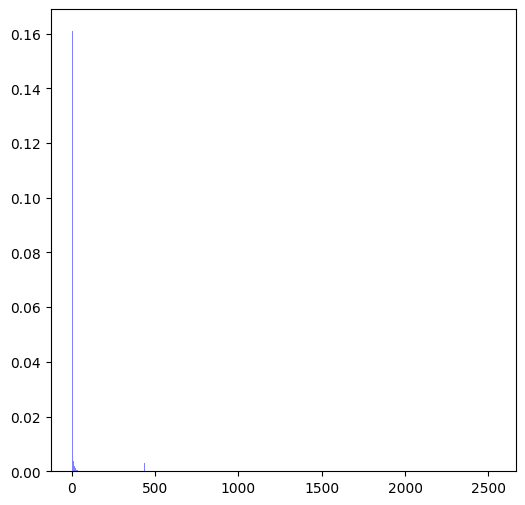

In [146]:
fig = plt.figure(figsize=(6,6))
plt.hist(z_scores, bins=500, density=True, alpha=0.5, color='blue')
plt.show()

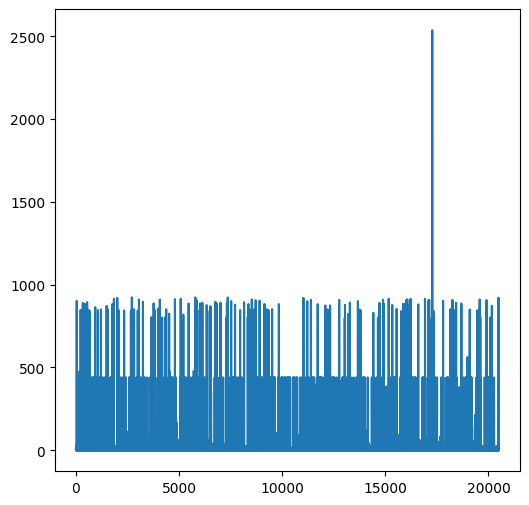

In [147]:
fig = plt.figure(figsize=(6,6))
plt.plot(z_scores)
plt.show()

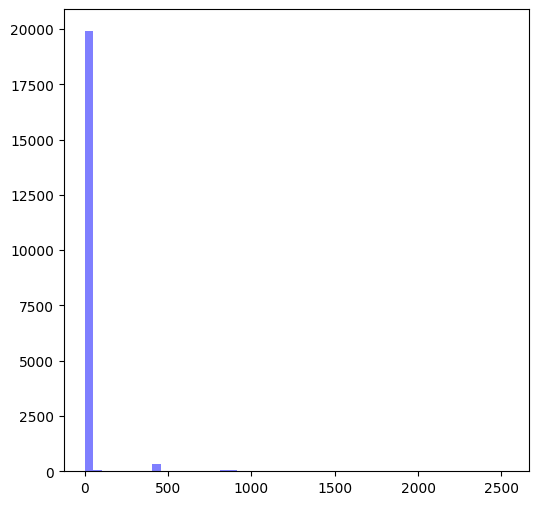

In [152]:
fig = plt.figure(figsize=(6,6))
plt.hist(z_scores, bins=50, alpha=0.5, color='blue')
plt.show()

# Evaluating

F1 Score: 0.9073724007561437
Precision: 0.8602150537634409
Recall: 0.96
Accuracy: 0.995219512195122


Text(50.722222222222214, 0.5, 'True Label')

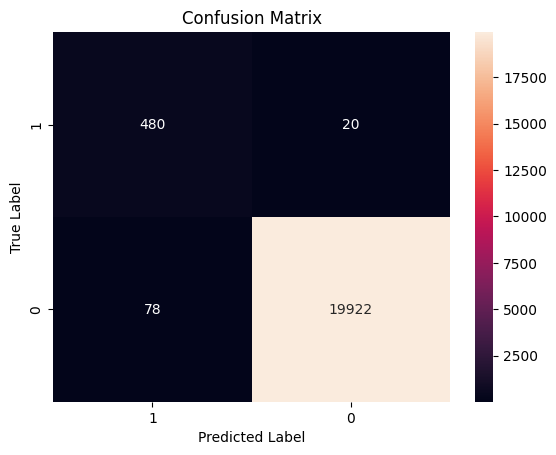

In [160]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

f1_test = f1_score(y_test, outliers)
precision_test = precision_score(y_test, outliers)
recall_test = recall_score(y_test, outliers)
accuracy_test = accuracy_score(y_test, outliers)

print(f"F1 Score: {f1_test}\nPrecision: {precision_test}\nRecall: {recall_test}\nAccuracy: {accuracy_test}")

cm = confusion_matrix(y_test, outliers)
plt.title("Confusion Matrix")
ax = sns.heatmap(cm, annot=True, fmt='0.0f')
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

In [150]:
tn, fp, fn, tp = cm.ravel()
print("False Negative Rate:", fn/(fn+tn))
print("False Positive Rate:", fp/(fp+tp))

False Negative Rate: 0.0010029084344599338
False Positive Rate: 0.13978494623655913
